In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re 
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alyah\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\alyah\AppData\Roaming\nltk_data...


True

In [ ]:
# printing stopwords in English these are the common words that do not add much meaning to a sentence
# we will remove these words to make our model better and easier to gneralize
# but we wont remove negations like 'not' as they add meaning to a sentence and are important for sentiment analysis
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [6]:
# data loading
df=pd.read_csv(r'C:\Users\alyah\VC\first_project\data\reddit_artist_posts_sentiment.csv')

In [7]:
df.shape

(31948, 2)

In [8]:
df.head()

,text,label
0,pitchfork track review: taylor swift’s “actual...,negative
1,taylor swift has regained the masters of her f...,positive
2,pitchfork review: taylor swift - the life of a...,neutral
3,taylor swift announced engagement,neutral
4,taylor swift - the fate of ophelia (official m...,neutral


In [9]:
df.isnull().sum()

text     0
label    0
dtype: int64

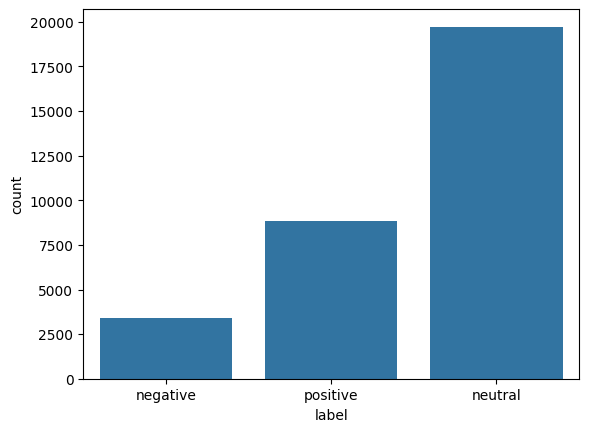

In [11]:
# cheacking the distribution of target variable
sns.countplot(x='label',data=df)
plt.show()

#### as we can see the dataset is unbalanced we will have to do some sampling techniques before training the model
### the best practice for our case is use weight = 'balanced' in the model parameters
### this will help the model to generalize better on the minority classes
### also use stratify=y while splitting the data to maintain the distribution of target variable in train and test set
#### this is better than undersmapling cause we will not loose any data this way
### also oversampling can lead to overfitting as we will be duplicating the data points and not good for text data
### undersmapling can lead to loss of important data points
### smote is not a good idea for text best use on numerical data
### alos data augmentaion in sntiment analysis is not a good idea as it can change the meaning of the sentence and lead to wrong labels




In [12]:
# convert labels to numerical values
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['label'].map(label_mapping)

In [13]:
df['label'].value_counts()

label
1    19728
2     8825
0     3395
Name: count, dtype: int64

In [15]:
# make a function to clean the text data ( regex, lower case, remove stopwords, lemmatization).
def clean_text(text):
    # List of important stopwords to keep
    important_words = [
        "aren't", "couldn't", "didn't", "doesn't", "don't", "hadn't", "hasn't", "haven't", "isn't",
        "mightn't", "mustn't", "needn't", "no", "not", "shan't", "shouldn't", "wasn't", "weren't",
        "won't", "wouldn't", "too", "very", "so", "just"
    ]
    
    stop_words = set(stopwords.words('english')) - set(important_words)

    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    cleaned_text = ' '.join(words)
    return cleaned_text

In [16]:
df['text'] = df['text'].apply(clean_text)

In [22]:
df['text'].sample(15).tolist()

['tate mcrae home',
 'make pop music like sound guitar so distorted might make eardrum bleed',
 'billie finneas break bad guy rolling stone',
 'grime new music coming nov',
 'bj thomas grammywinning singer enjoyed success pop country gospel chart hit just cant help believing raindrop keep fallin head hooked feeling died',
 'rachel chinouriri opening sabrina carpenter short n sweet tour paris open biggest popstar world internet still remind daily simply black make twice hard indie pop star',
 'aaron dessner defends taylor swift songwriting twitter xb httpspreviewredditoiiyweqdjpgwidthformatpjpgautowebpsfcfdaabedbcce',
 'heard taylor swift',
 'cyndi lauper announces farewell tour',
 'discussion merriamwebsters word watching standing stan',
 'ariana grandes next single way fan speculate cryptic tweet',
 'taylor swift tease new album life showgirl new height podcast',
 'nothing like mad woman prop foolery co excellent free poster resource',
 'mariah careys want christmas make merry move ba

In [23]:
# we import sklearn split train test
from sklearn.model_selection import train_test_split

In [24]:
x=df['text']
y=df['label']

In [26]:
print(x)

0        pitchfork track review taylor swift actually r...
1             taylor swift regained master first six album
2              pitchfork review taylor swift life showgirl
3                        taylor swift announced engagement
4           taylor swift fate ophelia official music video
                               ...                        
31943    feel like pop music getting terrible just impr...
31944    korea call kpop just regular pop music pop mus...
31945    less hour sunlight america summer era tour uk ...
31946             one woman every ten guy tinder nine girl
31947    concert ticket realistically get ticket next u...
Name: text, Length: 31948, dtype: object


In [28]:
print(y)

0        0
1        2
2        1
3        1
4        1
        ..
31943    0
31944    1
31945    1
31946    1
31947    1
Name: label, Length: 31948, dtype: int64


In [29]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(25558,) (6390,) (25558,) (6390,)


In [32]:
# now we conveert text data to numerical data using tfidf vectorizer
# beacuse machine learning models can only understand numerical data
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(x_train)
X_test = vectorizer.transform(x_test)

In [36]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 252071 stored elements and shape (25558, 20317)>
  Coords	Values
  (0, 13527)	0.30332685999648246
  (0, 15142)	0.2584335019977782
  (0, 5661)	0.3880575864807166
  (0, 2497)	0.3880575864807166
  (0, 19758)	0.4282528330444221
  (0, 18621)	0.4184641166990871
  (0, 8840)	0.2620019196636932
  (0, 541)	0.2742106389858077
  (0, 10779)	0.1941091800600246
  (1, 4187)	0.29612205263232116
  (1, 15708)	0.29286512809387144
  (1, 11801)	0.28570816596277676
  (1, 13822)	0.42543653742949694
  (1, 13909)	0.4089382292329684
  (1, 1540)	0.42543653742949694
  (1, 11895)	0.30562780229364694
  (1, 19442)	0.3166258711124337
  (1, 3488)	0.14842279040908843
  (2, 12486)	0.6262775818310938
  (2, 5039)	0.539749630205063
  (2, 4117)	0.5009202389784472
  (2, 393)	0.2559797675033531
  (3, 10730)	0.40593652510384043
  (3, 706)	0.2906283466157278
  (3, 15886)	0.4169567926860501
  :	:
  (25555, 19576)	0.41414231036270005
  (25555, 12679)	0.646811130997168
 

In [39]:
# now time to train a model
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

In [ ]:
# we will use linear svc for this task
# linear svc is optimized for large datasets and is faster than other svm variants
# it has no kernel tricks just a linear decision boundary
# linear svc works well for text classification tasks
model = LinearSVC(class_weight='balanced',max_iter=1000)


In [42]:
model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report

In [44]:
x_train_predictions = model.predict(X_train)


In [ ]:
# evaluate on training data
print("Accuracy:", accuracy_score(y_train, x_train_predictions))
print("Precision:", precision_score(y_train, x_train_predictions, average='weighted'))
print("Recall:", recall_score(y_train, x_train_predictions, average='weighted'))
print("F1 Score:", f1_score(y_train, x_train_predictions, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_train, x_train_predictions))

Accuracy: 0.9297675874481571
Precision: 0.9307876809778695
Recall: 0.9297675874481571
F1 Score: 0.9299938665337477
Confusion Matrix:
 [[ 2634    52    30]
 [  251 14728   803]
 [   53   606  6401]]


In [ ]:
# we goot great results on training data now time to evaluate on test data
# metrics on test data
x_test_predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, x_test_predictions))
print("Precision:", precision_score(y_test, x_test_predictions, average='weighted'))
print("Recall:", recall_score(y_test, x_test_predictions, average='weighted'))
print("F1 Score:", f1_score(y_test, x_test_predictions, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, x_test_predictions))

Accuracy: 0.7615023474178404
Precision: 0.7618954704346624
Recall: 0.7615023474178404
F1 Score: 0.7616821416393876
Confusion Matrix:
 [[ 399  215   65]
 [ 233 3249  464]
 [  66  481 1218]]


In [ ]:
# our scores on test data are decent its less than training data but not by much maybe so small overfitting
# but overall the model is performing well for a classication ml model
# we can try to improve it further by hyperparameter tuning and using more advanced models like ensemble models or deep learning models
# but for a baseline this is good enough
print(classification_report(y_test, x_test_predictions, target_names=['negative','neutral','positive']))

              precision    recall  f1-score   support

    negative       0.57      0.59      0.58       679
     neutral       0.82      0.82      0.82      3946
    positive       0.70      0.69      0.69      1765

    accuracy                           0.76      6390
   macro avg       0.70      0.70      0.70      6390
weighted avg       0.76      0.76      0.76      6390



In [ ]:
# we will save the model and vectorizer using joblib
# so we can load them later without retraining
import joblib

# Save the model
joblib.dump(model, r'c:\Users\alyah\VC\first_project\models\linear_svc.joblib')

# Save the vectorizer
joblib.dump(vectorizer, r'c:\Users\alyah\VC\first_project\models\tfidf_vectorizer.joblib')

['c:\\Users\\alyah\\VC\\first_project\\models\\tfidf_vectorizer.joblib']